# Introduction

This project is aimed at understanding and implementing some popular machine learning classification algorithms for the classification of shot accuracy in NBA regular season games. 

I gathered data from the NBA_API. It is detailed at this link https://github.com/swar/nba_api.

Here are some of the parts of the project 

1. Drawing of court, credits to Savvas Tjortjoglou for the court.
2. Taking Jaysom Tatum for a player, plotted shot locations, their accuracy, and jointplot.
3. Plotted zones of the court and classified shots into zones based on location. 
4. Classified shot location, accuracy, and the expected points from taking the shot.
5. Gathered all shot data from the 2023-24 NBA regular season. 
6. Preproccesed data to feed into models.
7. Trained Random Forest, XGBoost, and Neural Network models on this data. Then used hyperparameter tuning to find best parameters for the models.
8. Analyzed the results using accuracy and other metrics, RO-AU curves, feauture importance, and confusion matrices. 

# Court Drawing

In [1]:
pip install nba_api pandas numpy matplotlib seaborn scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players, teams
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    #just get current one if no axes specified
    if ax is None:
        ax = plt.gca()

   

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)

    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)

    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

# Shot Plotting

In [3]:
from nba_api.stats.endpoints import shotchartdetail

def get_shot_locations(player_name, season='2023-24'):
    player_dict = players.find_players_by_full_name(player_name)[0]
    player_id = player_dict['id']
     
    team_id = teams.find_teams_by_full_name('Boston Celtics')[0]['id']

    # Shot chart data
    shot_chart = shotchartdetail.ShotChartDetail(
        player_id=player_id,
        team_id=team_id,
        season_nullable=season,
        context_measure_simple='FGA'
    )
    
    shots_df = shot_chart.get_data_frames()[0]
    
    return shots_df[['LOC_X', 'LOC_Y', 'SHOT_MADE_FLAG']]

   LOC_X  LOC_Y  SHOT_MADE_FLAG
0    135    248               0
1    132    235               0
2    -23      6               0
3    143    218               1
4   -109    190               1


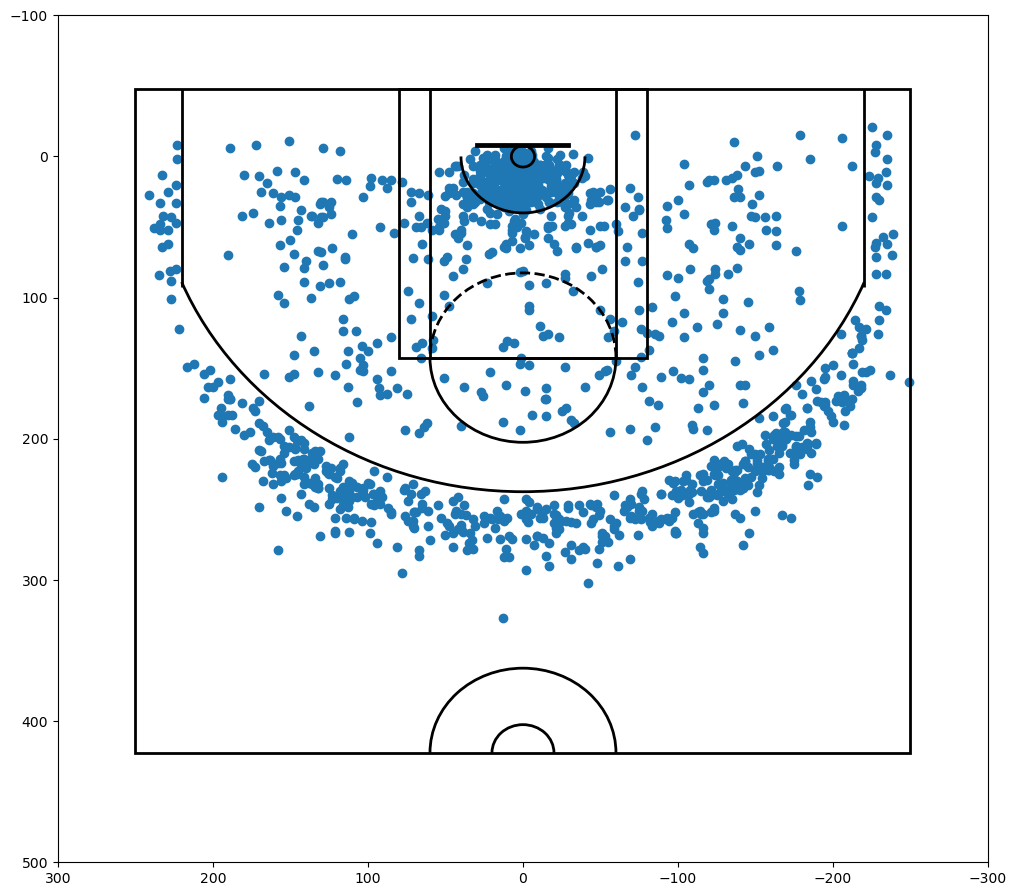

In [4]:
plt.figure(figsize=(12,11))
shots = get_shot_locations("Jayson Tatum")
print(shots.head())
plt.scatter(shots.LOC_X, shots.LOC_Y)
draw_court(outer_lines=True)
plt.xlim(300,-300)
plt.ylim(500,-100)
plt.show()

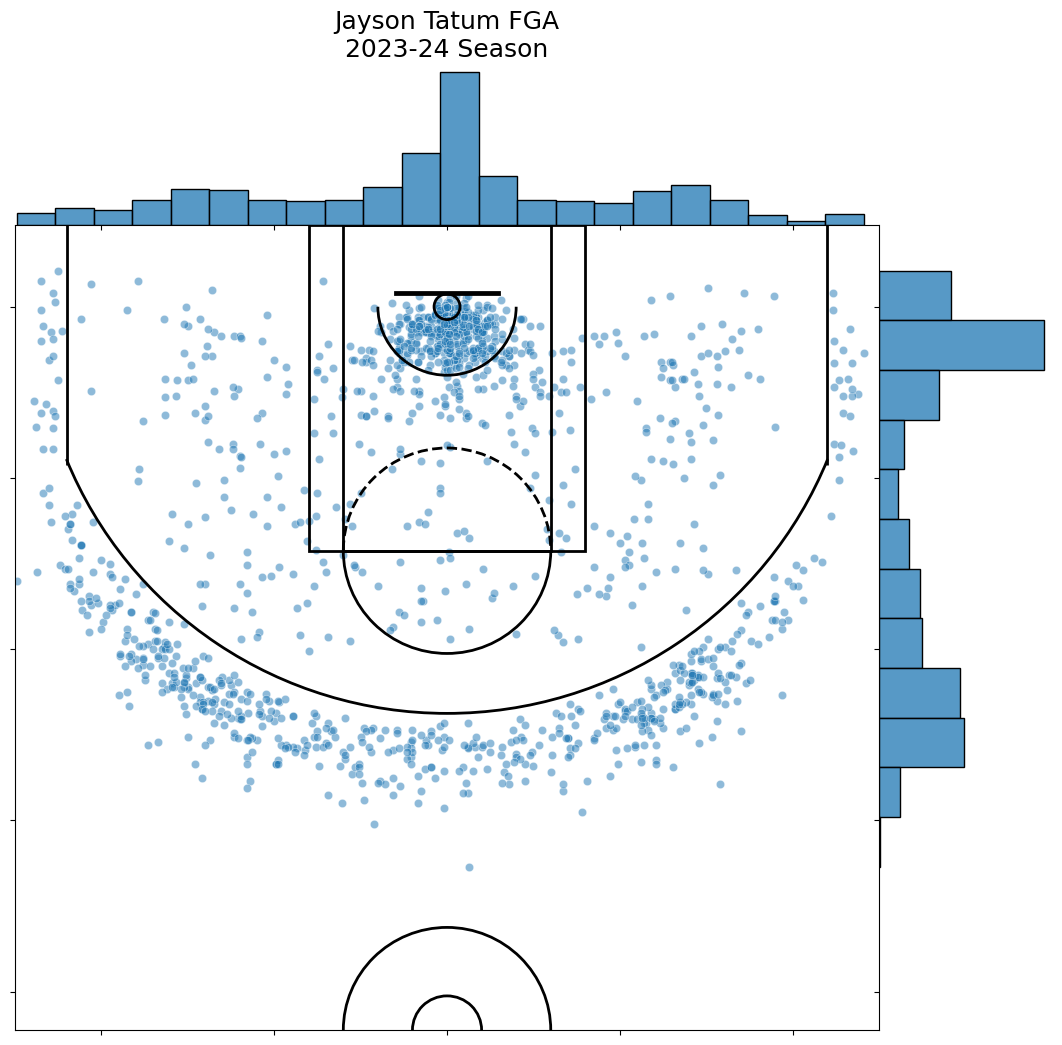

In [5]:
import seaborn as sns

shots = get_shot_locations("Jayson Tatum")
# Create joint plot
joint_shot_chart = sns.jointplot(
    data=shots,
    x='LOC_X',
    y='LOC_Y',
    kind='scatter',
    space=0,
    alpha=0.5
)


joint_shot_chart.fig.set_size_inches(12, 11)


ax = joint_shot_chart.ax_joint
draw_court(ax)


ax.set_xlim(-250, 250)
ax.set_ylim(422.5, -47.5)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(labelbottom=False, labelleft=False)

ax.set_title('Jayson Tatum FGA\n2023-24 Season', y=1.2, fontsize=18)

plt.show()

In [13]:
import matplotlib.pyplot as plt 
import numpy as np 


def classify_shot(x, y):
    '''
    Classify if a shot is worth 2 or 3 points
    '''
    x_feet = np.asarray(x)/12
    y_feet = np.asarray(y)/12


    
    distance = np.sqrt(x_feet**2 + y_feet**2)
    
    corner_three_y = 7.8  
    corner_three_x = 22.0  
    above_break_three = 23.75 
    

    points = np.full_like(distance, 2, dtype=int)
    

    corner_three_mask = (y_feet <= corner_three_y) & (np.abs(x_feet) >= corner_three_x)

    above_break_mask = (y_feet > corner_three_y) & (distance >= above_break_three)

    three_point_mask = corner_three_mask | above_break_mask
    points[three_point_mask] = 3
    
  
    if isinstance(x, (int, float)) and isinstance(y, (int, float)):
        return points.item()
    
    return points
    
def classify_shot_region(x, y):
    '''
    Convert coordinates from inches to feet
    '''
    x_feet = x / 12
    y_feet = y / 12
    
 
    distance = np.sqrt(x_feet**2 + y_feet**2)
    
 
    corner_three_y = 7.8

    is_corner_three = abs(x_feet) > 18.33 and y_feet < corner_three_y

    is_above_break = distance > 19.75 and y_feet > corner_three_y
    
    if distance <= 4:
        return 'restricted_area'
    elif distance <= 8:
        return 'paint_non_ra'
    elif y_feet <= 17 and abs(x_feet) <= 8:
        return 'paint'
    elif is_above_break:
        return 'above_break_three'
    elif is_corner_three:
        return 'corner_three'
    elif distance > 8:
        return 'long_mid_range'
    else:
        return 'close_range'


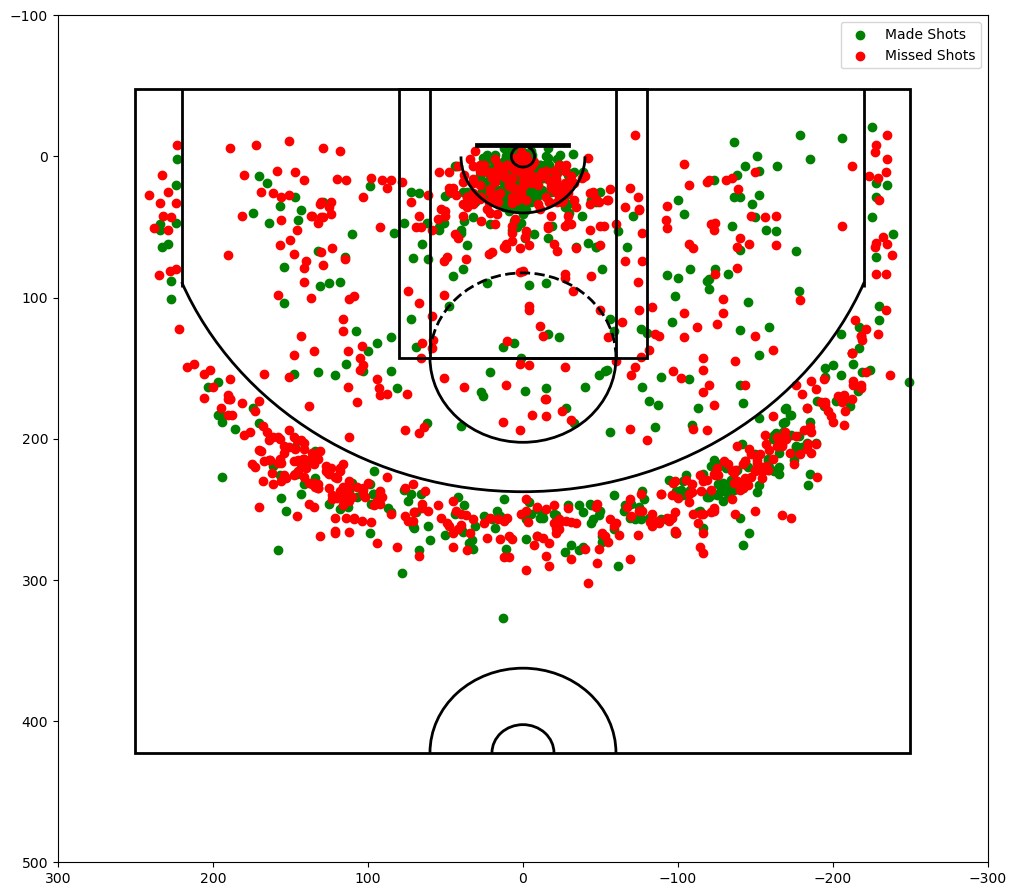

In [19]:
import matplotlib.pyplot as plt
shots = get_shot_locations("Jayson Tatum")

made_shots = shots[shots['SHOT_MADE_FLAG'] == 1]
missed_shots = shots[shots['SHOT_MADE_FLAG'] == 0]



plt.figure(figsize=(12,11))
plt.scatter(made_shots.LOC_X, made_shots.LOC_Y, color='green', label='Made Shots')
plt.scatter(missed_shots.LOC_X, missed_shots.LOC_Y, color='red', label='Missed Shots')
draw_court(outer_lines=True)
plt.xlim(300,-300)
plt.ylim(500,-100)
plt.legend()

plt.show()

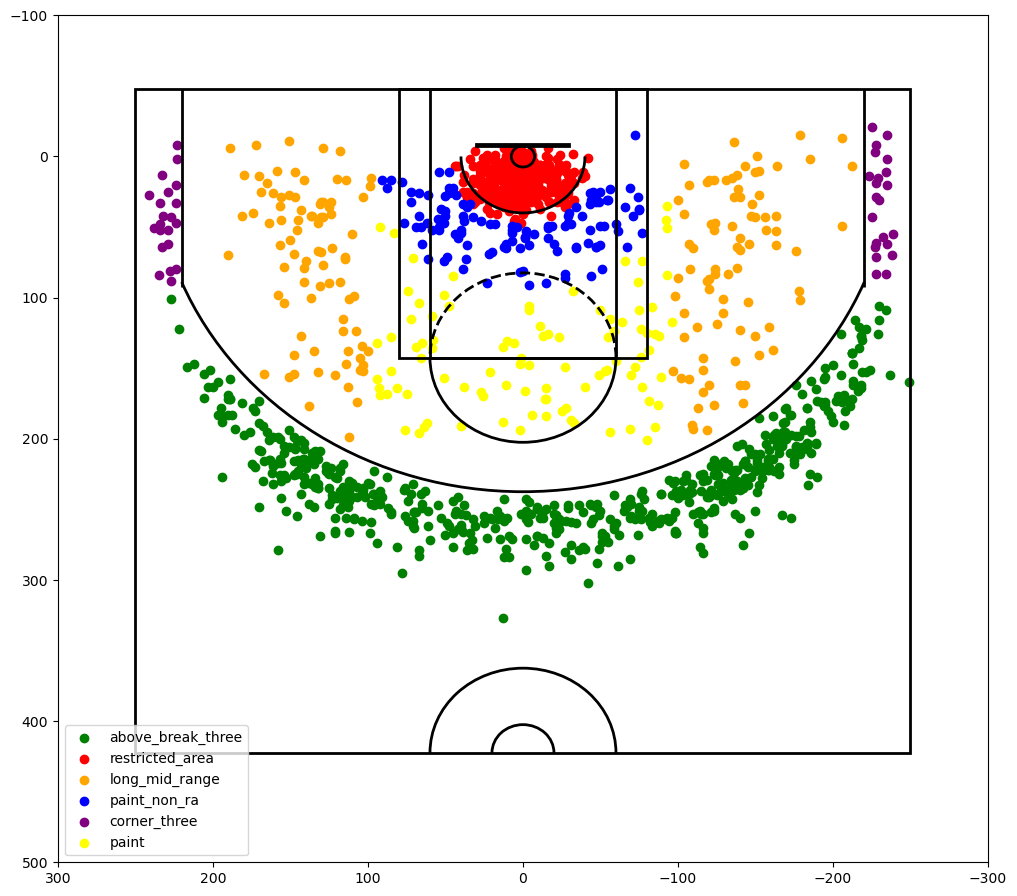

In [21]:
import matplotlib.pyplot as plt
shots = get_shot_locations("Jayson Tatum")

shots['region'] = shots.apply(lambda row: classify_shot_region(row['LOC_X'], row['LOC_Y']), axis=1)

plt.figure(figsize=(12,11))

regions = shots['region'].unique()
colors = {'restricted_area': 'red', 'paint_non_ra': 'blue', 'paint': 'yellow', 'above_break_three': 'green',
          'corner_three': 'purple', 'long_mid_range': 'orange', 'close_range': 'pink'}

for region in regions:
    region_shots = shots[shots['region'] == region]
    plt.scatter(region_shots.LOC_X, region_shots.LOC_Y, label=region, color=colors.get(region, 'black'))

draw_court(outer_lines=True)
plt.xlim(300,-300)
plt.ylim(500,-100)

plt.legend()

plt.show()

# Data Collection and Preproccesing

In [22]:
shooting_stats = pd.DataFrame()
shooting_stats['num_shots'] = shots.groupby('region').size()     
shooting_stats['fg_pct'] = shots.groupby('region')['SHOT_MADE_FLAG'].sum() / shooting_stats['num_shots'] 

region_shot_values = {
    'above_break_three': 3,
    'corner_three': 3,
    'long_mid_range': 2,
    'paint': 2,
    'paint_non_ra': 2,
    'restricted_area': 2
}

shooting_stats['shot_value'] = shooting_stats.index.map(region_shot_values)

shooting_stats['expected_points'] = shooting_stats['fg_pct'] * shooting_stats['shot_value']


print(shooting_stats)

                   num_shots    fg_pct  shot_value  expected_points
region                                                             
above_break_three        566  0.378092           3         1.134276
corner_three              43  0.348837           3         1.046512
long_mid_range           170  0.382353           2         0.764706
paint                     97  0.412371           2         0.824742
paint_non_ra             118  0.347458           2         0.694915
restricted_area          432  0.687500           2         1.375000


In [23]:
from nba_api.stats.endpoints import ShotChartDetail
from nba_api.stats.static import players
import pandas as pd
import time
from nba_api.stats.endpoints import CommonAllPlayers


def get_active_players_2023_24():
    """
    Get all active players for the 2023-24 NBA season
    """
    # Use CommonAllPlayers to get current season's active players
    players_data = CommonAllPlayers(
        is_only_current_season=1  # Only get current season's players
    )
    
    # Get the DataFrame of players
    players_df = players_data.get_data_frames()[0]
    
    # Filter for active players
    active_players = players_df[
        (players_df['ROSTERSTATUS'] == 1)  # Active players
    ]
    
    return active_players

    
def get_all_season_shots(season):
    
    shot_list = pd.DataFrame()  

    # Limit the number of players to process
    active_players = get_active_players_2023_24()
    print(active_players)
    active_players_names = active_players['PERSON_ID']

    for player in active_players_names:
        player_id = player  
        print(player_id)
        

        try:
            # Fetch shot data for the player
            shot_data = ShotChartDetail(
                team_id=0,  
                player_id=player_id,  
                season_nullable=season,
                context_measure_simple='FGA', 
                timeout=60  
            )
            # Convert the shot data to a DataFrame
            shot_df = shot_data.get_data_frames()[0]
            shot_list = pd.concat([shot_list, shot_df], ignore_index=True)
        except Exception as e:
            None

    return shot_list



In [24]:
season_shots = get_all_season_shots('2023-24')

print("DataFrame shape:", season_shots.shape)  # Will show (rows, columns)

print("\nFirst few rows:")
pd.set_option('display.max_columns', None)
print(season_shots.head(50))

     PERSON_ID DISPLAY_LAST_COMMA_FIRST DISPLAY_FIRST_LAST  ROSTERSTATUS  \
0      1630173        Achiuwa, Precious   Precious Achiuwa             1   
1       203500            Adams, Steven       Steven Adams             1   
2      1628389             Adebayo, Bam        Bam Adebayo             1   
3      1630534            Agbaji, Ochai       Ochai Agbaji             1   
4      1630583            Aldama, Santi       Santi Aldama             1   
..         ...                      ...                ...           ...   
545     203469             Zeller, Cody        Cody Zeller             1   
546    1627826             Zubac, Ivica        Ivica Zubac             1   
547    1641783        da Silva, Tristan   Tristan da Silva             1   
548    1628427           Čančar, Vlatko      Vlatko Čančar             1   
549     203967             Šarić, Dario        Dario Šarić             1   

    FROM_YEAR TO_YEAR        PLAYERCODE       PLAYER_SLUG     TEAM_ID  \
0        2020 

In [25]:
season_shots.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM'],
      dtype='object')

season_shots.isnull().sum()

In [26]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

season_shots_used = pd.DataFrame()
season_shots_used['RESULT'] = season_shots['SHOT_MADE_FLAG']
season_shots_used['PERIOD'] = season_shots['PERIOD']
season_shots_used['M_REM'] = season_shots['MINUTES_REMAINING']
season_shots_used['S_REM'] = season_shots['SECONDS_REMAINING']
season_shots_used['DISTANCE'] = season_shots['SHOT_DISTANCE']
season_shots_used['X'] = season_shots['LOC_X']
season_shots_used['Y'] = season_shots['LOC_Y']

distance_mapping = {'Less Than 8 ft.':1,'8-16 ft.':2,
                    '16-24 ft.':3, '24+ ft.':4}
season_shots_used['D_CLASS'] = season_shots['SHOT_ZONE_RANGE'].map(distance_mapping)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
season_shots_used['SHOT_ZONE_BASIC'] = season_shots['SHOT_ZONE_BASIC']
season_shots_used['ACTION_TYPE'] = season_shots['ACTION_TYPE']

# Extract the column to be one-hot encoded
sss = season_shots_used[['SHOT_ZONE_BASIC']]
ccc = season_shots_used[['ACTION_TYPE']]

# Define the ColumnTransformer
c_transf = ColumnTransformer([
    ('onehot', OneHotEncoder(), [0]) 
], remainder='drop')  

# Apply the transformation
sss_transformed = c_transf.fit_transform(sss)

# Convert the transformed data to a DataFrame
sss_df = pd.DataFrame(sss_transformed.toarray() if hasattr(sss_transformed, 'toarray') else sss_transformed)

# Add column names to the one-hot encoded DataFrame
action_type_categories = c_transf.named_transformers_['onehot'].get_feature_names_out(['SHOT_ZONE_BASIC'])
sss_df.columns = action_type_categories

# Concatenate the one-hot encoded DataFrame with the original DataFrame
season_shots_used = pd.concat([season_shots_used.reset_index(drop=True), sss_df.reset_index(drop=True)], axis=1)

ccc_transformed = c_transf.fit_transform(ccc)

ccc_df = pd.DataFrame(ccc_transformed.toarray() if hasattr(ccc_transformed, 'toarray') else ccc_transformed)

action_type_categories = c_transf.named_transformers_['onehot'].get_feature_names_out(['ACTION_TYPE'])
ccc_df.columns = action_type_categories

season_shots_used = pd.concat([season_shots_used.reset_index(drop=True), ccc_df.reset_index(drop=True)], axis=1)

season_shots_used.drop(columns=['SHOT_ZONE_BASIC'], inplace=True)
season_shots_used.drop(columns=['ACTION_TYPE'], inplace=True)
print(season_shots_used.head(30))

   RESULT PERIOD M_REM S_REM DISTANCE     X    Y  D_CLASS  \
0       1      1     1    49        1    -6   16      1.0   
1       0      1     0    11       23   232    4      4.0   
2       0      2     8    49       22  -229    1      4.0   
3       1      4     9    30        0    -7   -2      1.0   
4       0      1     0    32       26  -200  177      4.0   
5       1      2     7    11        1   -12   11      1.0   
6       1      3     5    35        1    11   16      1.0   
7       0      3     4    13        0     0    0      1.0   
8       1      1     1    27        1    10    3      1.0   
9       1      2    10     7        3   -29    8      1.0   
10      0      2     7    46        2    -7   29      1.0   
11      1      4     8    27        1    15   13      1.0   
12      0      1     2    19       26   212  162      4.0   
13      0      2    11    16        3    27   21      1.0   
14      0      3     3    45        2   -20   19      1.0   
15      0      3     0  

In [27]:
from sklearn.model_selection import train_test_split

X, y = season_shots_used.iloc[:, 1:].values, season_shots_used.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=0, stratify=y)
y_train = y_train.astype(int)
y_test = y_test.astype(int)
print(X_train[:5])
print(X_test[:5])
print(y_train[:5])
print(y_test[:5])


[[3 2 42 1 10 13 1.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0]
 [1 0 0 25 -40 253 4.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0]
 [2 2 6 25 -194 159 4.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0]
 [1 6 38 24 -234 78 4.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  0.0 0.0 0.0 0.0 0.0 0.0 0.0]


In [29]:
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

# Model Training

 1) Y                              0.157834
 2) DISTANCE                       0.149146
 3) X                              0.148305
 4) S_REM                          0.131240
 5) M_REM                          0.078460
 6) SHOT_ZONE_BASIC_Restricted Area 0.072966
 7) D_CLASS                        0.045831
 8) PERIOD                         0.041765
 9) ACTION_TYPE_Cutting Dunk Shot  0.019310
10) ACTION_TYPE_Running Dunk Shot  0.018457
11) SHOT_ZONE_BASIC_Above the Break 3 0.017144
12) ACTION_TYPE_Tip Layup Shot     0.016578
13) ACTION_TYPE_Driving Layup Shot 0.013780
14) ACTION_TYPE_Jump Shot          0.009933
15) ACTION_TYPE_Alley Oop Dunk Shot 0.008149
16) SHOT_ZONE_BASIC_In The Paint (Non-RA) 0.008109
17) ACTION_TYPE_Dunk Shot          0.005381
18) ACTION_TYPE_Driving Dunk Shot  0.004986
19) ACTION_TYPE_Cutting Layup Shot 0.004478
20) ACTION_TYPE_Layup Shot         0.004363
21) ACTION_TYPE_Pullup Jump shot   0.003716
22) ACTION_TYPE_Driving Floating Jump Shot 0.002859
23) SHOT_ZON

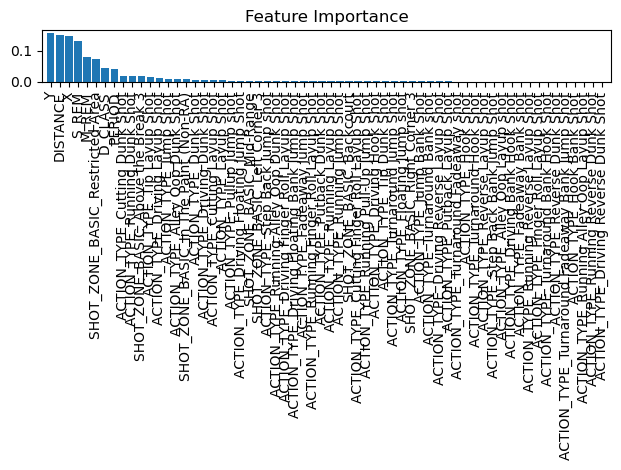

In [30]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

clf = RandomForestClassifier(
    n_estimators=100,      
    max_depth=20,           
    min_samples_split=5,   
    min_samples_leaf=2,     
    random_state=1          
)

clf.fit(X_train_std, y_train)

importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]

labels = season_shots_used.columns[1:]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, labels[indices[f]], importances[indices[f]]))

plt.title('Feature Importance')
plt.bar(range(X_train.shape[1]), importances[indices],align='center')

plt.xticks(range(X_train.shape[1]), labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()

plt.show()

In [31]:
y_pred = clf.predict(X_test_std)
print('Test Accuracy: %.3f' % clf.score(X_test_std, y_test))

Test Accuracy: 0.627


In [33]:
from sklearn.metrics import accuracy_score
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'max_depth': 3,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
    'eval_metric': 'logloss'
}

num_rounds = 100  # number of boosting rounds
model = xgb.train(params, dtrain, num_rounds)

y_pred = model.predict(dtest)
y_pred_binary = [1 if p > 0.50 else 0 for p in y_pred]

accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 62.79%


In [34]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class ShotsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

#neural network
class ShotPredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # Add this sigmoid layer
            )
    def forward(self, x):
        return self.layers(x)

#data
X_train_tensor = torch.FloatTensor(X_train_std)
y_train_tensor = torch.FloatTensor(y_train)
train_dataset = ShotsDataset(X_train_std, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#model, loss function, and optimizer
model = ShotPredictor(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}')


Epoch [10/50], Loss: nan
Epoch [20/50], Loss: nan
Epoch [30/50], Loss: nan
Epoch [40/50], Loss: nan
Epoch [50/50], Loss: nan


In [35]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_std)
    y_test_tensor = torch.FloatTensor(y_test)
    test_outputs = model(X_test_tensor).squeeze()
    predictions = (test_outputs > 0.5).float()
    accuracy = (predictions == y_test_tensor).float().mean()
    print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.5228


# Model Evaluation

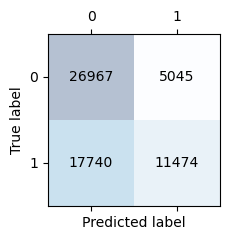

In [36]:
from sklearn.metrics import confusion_matrix

confmat = confusion_matrix(y_true=y_test, y_pred=y_pred_binary)

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()

plt.show()

In [39]:
from sklearn.metrics import classification_report
y_pred_binary = (y_pred > 0.5).astype(int)
report = classification_report(y_test, y_pred_binary)
print("Report Statistics:", report)

Report Statistics:               precision    recall  f1-score   support

           0       0.60      0.84      0.70     32012
           1       0.69      0.39      0.50     29214

    accuracy                           0.63     61226
   macro avg       0.65      0.62      0.60     61226
weighted avg       0.65      0.63      0.61     61226



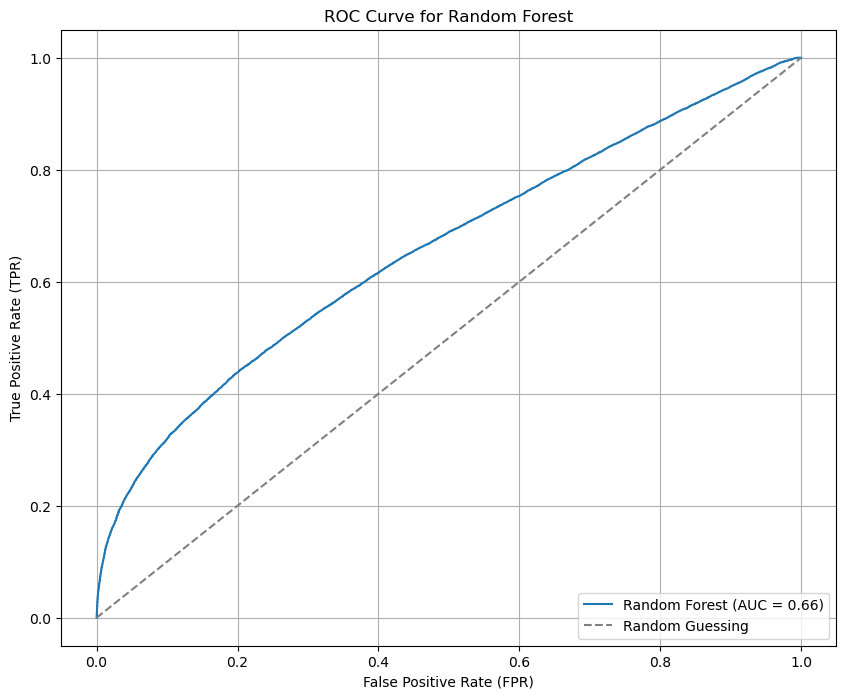

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
models = {
    "Random Forest": clf,
}

# Plot ROC curve for each model
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
   
    model.fit(X_train_std, y_train)
    
    y_pred_proba = model.predict_proba(X_test_std)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guessing")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Conclusion

In the end I was surprised at these models performance on this task. The accuracy score, AU-RO curve, and metrics of analyzing the performance were lower than expected. The accuracy on the best model was in the mid 60 percents. This is better than random guessing, but not as significantly as I would have thought. This could be due to lack of data that is used in non-free datasets. I wanted to access data such as defender distance but this dataset did not include that. Other aspects of lower than expectd performance could bemodel limitations or model over/under-fitting.